In [10]:
## saving the model
import joblib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from mlxtend.plotting import  plot_decision_regions
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
%matplotlib inline
import matplotlib.pyplot as plt

## Classification using load_breast_cancer

In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns= data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, stratify= y, random_state= 42)

In [5]:
model = Pipeline([
    ('Impute', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler()),
    ('model',LogisticRegressionCV(cv = 5, max_iter= 1000, random_state= 42)),
])
model.fit(X_train, y_train)

Pipeline(steps=[('Impute', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegressionCV(cv=5, max_iter=1000, random_state=42))])

In [6]:
y_pred_prob = model.predict_proba(X_test)[:,1]

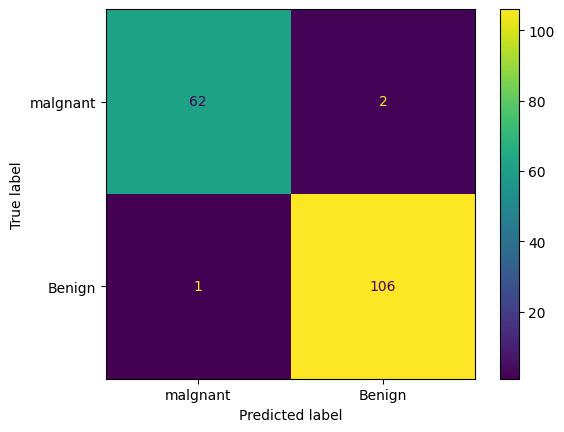

In [13]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels= [0,1])
d = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= ["malgnant", "Benign"])
d.plot()
plt.show()

## Save the model

In [ ]:
joblib.dump(model, "breast_cancer_pipeline.pkl")
# load_pipeline = joblib.load("breast_cancer_pipeline.pkl")  ## To load the model.

['breast_cancer_pipeline.pkl']

## using XGboost

In [19]:
import xgboost as xgb
model = xgb.XGBClassifier(
     n_estimators=100,      # number of trees
    max_depth=5,           # tree depth
    learning_rate=0.1,     # step size shrinkage
    subsample=0.8,         # row sampling
    colsample_bytree=0.8   # column sampling
)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

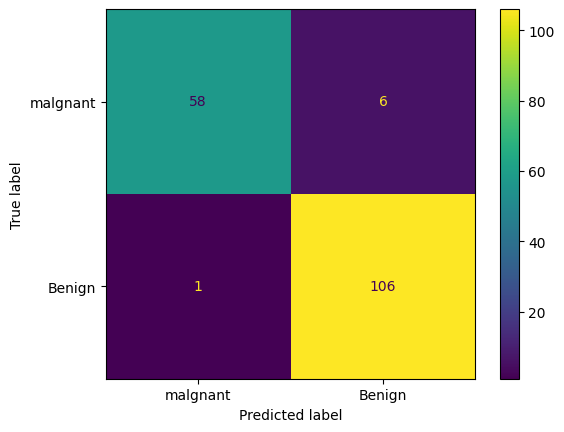

In [26]:
y_pred_xgb = model.predict(X_test)
accuracy_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels= [0,1])
d_xgb = ConfusionMatrixDisplay(confusion_matrix= cm_xgb, display_labels= ["malgnant", "Benign"])
d_xgb.plot()
plt.show()
## data is small for Xgboost, may be that's why it has less accuracy
